# Classify New Samples

In [ ]:
import csv
import os

def load_play_ball(path):
    with open(path, newline="") as f:
        reader = csv.DictReader(f)
        rows = []
        for row in reader:
            cleaned = {key.strip(): value.strip() for key, value in row.items()}
            rows.append(cleaned)
    return rows

def built_in_play_ball_data():
    return [
        {"Day": "D1", "Outlook": "Sunny", "Temperature": "Hot", "Humidity": "High", "Wind": "Weak", "Play ball": "No"},
        {"Day": "D2", "Outlook": "Sunny", "Temperature": "Hot", "Humidity": "High", "Wind": "Strong", "Play ball": "No"},
        {"Day": "D3", "Outlook": "Overcast", "Temperature": "Hot", "Humidity": "High", "Wind": "Weak", "Play ball": "Yes"},
        {"Day": "D4", "Outlook": "Rain", "Temperature": "Mild", "Humidity": "High", "Wind": "Weak", "Play ball": "Yes"},
        {"Day": "D5", "Outlook": "Rain", "Temperature": "Cool", "Humidity": "Normal", "Wind": "Weak", "Play ball": "Yes"},
        {"Day": "D6", "Outlook": "Rain", "Temperature": "Cool", "Humidity": "Normal", "Wind": "Strong", "Play ball": "No"},
        {"Day": "D7", "Outlook": "Overcast", "Temperature": "Cool", "Humidity": "Normal", "Wind": "Strong", "Play ball": "Yes"},
        {"Day": "D8", "Outlook": "Sunny", "Temperature": "Mild", "Humidity": "High", "Wind": "Weak", "Play ball": "No"},
        {"Day": "D9", "Outlook": "Sunny", "Temperature": "Cool", "Humidity": "Normal", "Wind": "Weak", "Play ball": "Yes"},
        {"Day": "D10", "Outlook": "Rain", "Temperature": "Mild", "Humidity": "Normal", "Wind": "Weak", "Play ball": "Yes"},
        {"Day": "D11", "Outlook": "Sunny", "Temperature": "Mild", "Humidity": "Normal", "Wind": "Strong", "Play ball": "Yes"},
        {"Day": "D12", "Outlook": "Overcast", "Temperature": "Mild", "Humidity": "High", "Wind": "Strong", "Play ball": "Yes"},
        {"Day": "D13", "Outlook": "Overcast", "Temperature": "Hot", "Humidity": "Normal", "Wind": "Weak", "Play ball": "Yes"},
        {"Day": "D14", "Outlook": "Rain", "Temperature": "Mild", "Humidity": "High", "Wind": "Strong", "Play ball": "No"},
    ]

candidate_paths = [
    "dataset.csv",
    "playball.csv",
    "./dataset.csv",
    "../dataset.csv",
    "/kaggle/input/datasets/enigmatronix13/playball/dataset.csv",
]

data_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if data_path is not None:
    data = load_play_ball(data_path)
    print(f"Loaded {len(data)} rows from: {data_path}")
else:
    data = built_in_play_ball_data()
    print("Dataset file not found. Using built-in Play Ball dataset.")

target = "Play ball"
features = [key for key in data[0].keys() if key not in ("Day", target)]

In [ ]:
from collections import Counter
from math import log2

def entropy(rows, target_col):
    counts = Counter(row[target_col] for row in rows)
    total = len(rows)
    return -sum((count / total) * log2(count / total) for count in counts.values())

def split_rows(rows, feature):
    groups = {}
    for row in rows:
        value = row[feature]
        groups.setdefault(value, []).append(row)
    return groups

def information_gain(rows, feature, target_col):
    base = entropy(rows, target_col)
    groups = split_rows(rows, feature)
    total = len(rows)
    weighted = sum((len(group) / total) * entropy(group, target_col) for group in groups.values())
    return base - weighted

def majority_label(rows, target_col):
    return Counter(row[target_col] for row in rows).most_common(1)[0][0]

def id3(rows, features, target_col):
    labels = [row[target_col] for row in rows]
    if len(set(labels)) == 1:
        return labels[0]
    if not features:
        return majority_label(rows, target_col)

    best_feature = max(features, key=lambda f: information_gain(rows, f, target_col))
    tree = {best_feature: {}}
    remaining_features = [f for f in features if f != best_feature]

    for value, subset in split_rows(rows, best_feature).items():
        tree[best_feature][value] = id3(subset, remaining_features, target_col)
    return tree

def tree_to_rules(tree, target_col, prefix=None):
    if prefix is None:
        prefix = []
    if not isinstance(tree, dict):
        condition = " and ".join(prefix) if prefix else "TRUE"
        return [(condition, tree)]

    feature = next(iter(tree))
    rules = []
    for value, subtree in tree[feature].items():
        rules.extend(tree_to_rules(subtree, target_col, prefix + [f"{feature}={value}"]))
    return rules

def classify_with_tree(tree, sample, default_label):
    node = tree
    while isinstance(node, dict):
        feature = next(iter(node))
        value = sample.get(feature)
        if value not in node[feature]:
            return default_label
        node = node[feature][value]
    return node

tree = id3(data, features, target)
rules = tree_to_rules(tree, target)
default_label = majority_label(data, target)

print("Learned ID3 rules:")
for condition, label in rules:
    print(f"IF {condition} THEN {target}={label}")

IF Outlook=Overcast THEN Play ball=Yes
IF Outlook=Rain and Wind=Strong THEN Play ball=No
IF Outlook=Rain and Wind=Weak THEN Play ball=Yes
IF Outlook=Sunny and Humidity=High THEN Play ball=No
IF Outlook=Sunny and Humidity=Normal THEN Play ball=Yes


In [ ]:
new_samples = [
    {"Outlook": "Sunny", "Temperature": "Cool", "Humidity": "High", "Wind": "Strong"},
    {"Outlook": "Rain", "Temperature": "Mild", "Humidity": "Normal", "Wind": "Weak"},
    {"Outlook": "Overcast", "Temperature": "Hot", "Humidity": "High", "Wind": "Weak"}
],

predictions = []
for i, sample in enumerate(new_samples, start=1):
    pred = classify_with_tree(tree, sample, default_label=default_label)
    predictions.append(pred)
    print(f"Sample {i}: {sample} -> {target}={pred}")

Sample 1: {'Outlook': 'Sunny', 'Temperature': 'Cool', 'Humidity': 'High', 'Wind': 'Strong'} -> Play ball=No
Sample 2: {'Outlook': 'Rain', 'Temperature': 'Mild', 'Humidity': 'Normal', 'Wind': 'Weak'} -> Play ball=Yes
Sample 3: {'Outlook': 'Overcast', 'Temperature': 'Hot', 'Humidity': 'High', 'Wind': 'Weak'} -> Play ball=Yes


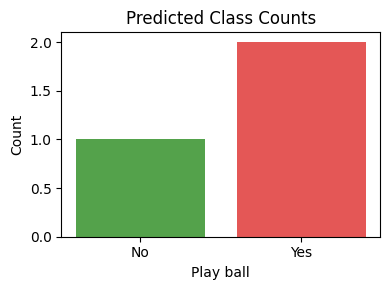

In [8]:
import matplotlib.pyplot as plt
from collections import Counter

counts = Counter(predictions)
labels = list(counts.keys())
values = [counts[label] for label in labels]

plt.figure(figsize=(4, 3))
plt.bar(labels, values, color=["#54A24B", "#E45756"])
plt.title("Predicted Class Counts")
plt.xlabel("Play ball")
plt.ylabel("Count")
plt.tight_layout()
plt.show()